##Tasca S10.01. Analítica de dades en Pandas

Descripció
En aquesta tasca t’enfrontaràs a un exercici de neteja i analítica de dades.

Tenim un dataset provinent d’una enquesta als nostres treballadors i treballadors, i hem de garantir que les dades es processen correctament, tant en format com en llegibilitat.

#Nivell 1
**1.**
Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.

Mostra les primeres 10 files.

Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [10]:
import pandas as pd

#Importa com un DataFrame l'arxiu sprint10.xlsx.
trabajadores_excel = pd.read_excel("sprint10.xlsx")
#Assegura't que el fitxer s'importa correctament.
trabajadores_filas = trabajadores_excel.drop([0,1], axis=0)
trabajadores_cabecera = trabajadores_filas.rename(columns = trabajadores_filas.iloc[0])
trabajadores_cabecera = trabajadores_cabecera.drop(trabajadores_cabecera.index[0])
trabajadores = trabajadores_cabecera.drop(trabajadores_cabecera.columns[0], axis=1).reset_index(drop=True)
#Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
trabajadores_sort = trabajadores.sort_values(by=["País d'origen", "Ciutat"])
#Mostra les primeres 10 files.
display(trabajadores_sort.head(10))

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,True,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,True,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,True,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,True,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,True,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,True,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,True,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,True,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,True,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,True,Grup B


In [11]:
#Addicionalment, fes un print on comprovi que el DNI només té valors únics.
duplicados_dni =trabajadores_sort[trabajadores_sort["DNI"].duplicated(keep=False)]
display(duplicados_dni)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional


**2.**
Crea una columna que sigui el nom complet.

Crea una columna si la persona és nascuda a Espanya o no.

Posa el DNI com a índex del DataFrame (noms de files).

Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.

Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

Mostra tots els canvis que has realitzat en una sola taula.

In [12]:
import numpy as np

#Crea una columna que sigui el nom complet.
Nom_Complet = trabajadores_sort["Nom"] + " " + trabajadores_sort["Cognoms"]
trabajadores_sort.insert(2, "Nom_complet", Nom_Complet)
#Crea una columna si la persona és nascuda a Espanya o no.
trabajadores_sort["Nascuts_ESP"] = trabajadores_sort["País d'origen"].apply(lambda x:1 if x=="Espanya" else 0)
#Posa el DNI com a índex del DataFrame (noms de files).
trabajadores_sort = trabajadores_sort.set_index("DNI")
trabajadores_dni = trabajadores_sort
#Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
trabajadores_dni = trabajadores_dni.rename(columns={"Dia de Naixement":"Dia", "Mes de Naixement":"Mes", "Any de Naixement":"Any"})
#Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).
trabajadores_dni["Gènere"] = trabajadores_dni["Gènere"].replace({"H":"Home","D":"Dona","A":np.nan,"NC":np.nan})
#Mostra tots els canvis que has realitzat en una sola taula.
trabajadores_dni.head()

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nascuts_ESP
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,NaN,951 €,NaN,True,Grup A,0
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,True,NaN,Grup B,0
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,True,Grup B,0
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,True,NaN,Grup B,0
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,True,NaN,Grup D,0


**3.**
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [13]:
trabajadores_dni["Fills"] = trabajadores_dni["Fills"].apply(lambda x: "Sí" if x==True else "No")
del trabajadores_dni["No Fills"]

trabajadores_dni

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nascuts_ESP
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,NaN,951 €,No,Grup A,0
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Sí,Grup B,0
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,0
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Sí,Grup B,0
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Sí,Grup D,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,Grup B,0
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Sí,Grup A,0
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,Manchester,28,8,1952,NaN,1.023 €,No,Grup A,0


**4.**
Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.

Ordena la taula en funció del sou mig.

In [14]:
#convertir "Salari mensual" a tipus de dada numérica.
trabajadores_dni["Salari mensual"] = (trabajadores_dni["Salari mensual"].str.replace(" €", "", regex=False)
                                      .str.replace(".", "", regex=False).astype(float))

In [15]:
resumen_sueldo_genero = trabajadores_dni.pivot_table(index="Gènere",
                                                values="Salari mensual", 
                                                aggfunc=["mean","median","min","max"], 
                                                margins=True, margins_name="Total").round(2)
resumen_sueldo_genero = resumen_sueldo_genero.rename(columns={"mean":"Sou mig","median":"Sou medià","min":"Sou mínim","max":"Sou máxim"})
resumen_sueldo_genero

,Sou mig,Sou medià,Sou mínim,Sou máxim
,Salari mensual,Salari mensual,Salari mensual,Salari mensual
Gènere,,,,
Dona,1469.44,1361.5,665.0,3021.0
Home,1643.25,1531.0,737.0,3356.0
Total,1557.23,1431.0,665.0,3356.0


**5.**
Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).

Afegeix-hi les mitjanes als marges de la taula.

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [16]:
import seaborn as sns
import jinja2

resumen_genero_pais = trabajadores_dni.pivot_table(index="Gènere",
                                                   columns="País d'origen",
                                                   values="Salari mensual",
                                                   aggfunc="mean",
                                                   margins=True, margins_name="Total")
resumen_genero_pais = resumen_genero_pais.rename(columns={"mean":"Sou mig"})
resumen_heatmap = resumen_genero_pais.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=None)
resumen_heatmap

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Total
Gènere,,,,,,,,,,,
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Total,1896.40,1475.33,1522.14,1574.59,1462.73,1426.42,1457.62,1563.74,1493.12,1355.73,1557.23


**6.**
Crea una columna nova que sigui la data de naixement en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.

Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [17]:
#convertir a tipus de dada numérica.
trabajadores_dni["Dia"] = trabajadores_dni["Dia"].astype(int)
trabajadores_dni["Mes"] = trabajadores_dni["Mes"].astype(int)
trabajadores_dni["Any"] = trabajadores_dni["Any"].astype(int)

In [18]:
#Crea una columna nova que sigui la data de naixement en format Datetime a partir de les columnes dia, mes i any.
from datetime import datetime

data_naixement = trabajadores_dni.apply(lambda fila: datetime(fila["Any"], fila["Mes"], fila["Dia"]), axis=1)
trabajadores_dni.insert(5, "Data_naixement", data_naixement)
trabajadores_dni.drop(["Dia", "Mes", "Any"], axis=1, inplace=True)
trabajadores_dni.head()

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Data_naixement,Gènere,Salari mensual,Fills,Grup Professional,Nascuts_ESP
DNI,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,1976-10-22,NaN,951.0,No,Grup A,0
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,1958-02-02,Dona,1769.0,Sí,Grup B,0
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,2005-10-23,Dona,2013.0,No,Grup B,0
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,1950-08-11,Dona,1557.0,Sí,Grup B,0
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,1985-11-22,Home,2754.0,Sí,Grup D,0


In [ ]:
#Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
def calculo_edad(nacimiento):
    """
    función para calcular edad actual usuarios.
    input:
        fecha de nacimiento
    output:
        edad actual en años.    
    """
    hoy = datetime.now()
    edad = hoy.year - nacimiento.year - ((hoy.month, hoy.day) < (nacimiento.month, nacimiento.day))
    return edad

In [20]:
#Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.
trabajadores_dni["Edat_actual"] = trabajadores_dni["Data_naixement"].apply(calculo_edad)

trabajadores_dni.head()

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Data_naixement,Gènere,Salari mensual,Fills,Grup Professional,Nascuts_ESP,Edat_actual
DNI,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,1976-10-22,NaN,951.0,No,Grup A,0,49
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,1958-02-02,Dona,1769.0,Sí,Grup B,0,68
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,2005-10-23,Dona,2013.0,No,Grup B,0,20
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,1950-08-11,Dona,1557.0,Sí,Grup B,0,75
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,1985-11-22,Home,2754.0,Sí,Grup D,0,40


#Nivell 2

**1.**
Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":["5%","3,5%","2%","8%"]})

In [21]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":["5%","3,5%","2%","8%"]})
df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [22]:
#Adjunta la columna "Increment" al dataframe del nivell anterior.
df_increment["Increment"] = df_increment["Increment"].str.replace(",",".")

trabajadores_inc = pd.merge(trabajadores_dni, df_increment, left_on="Grup Professional", right_on="Grup", how="left")
del trabajadores_inc["Grup"]
trabajadores_inc.head()

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Data_naixement,Gènere,Salari mensual,Fills,Grup Professional,Nascuts_ESP,Edat_actual,Increment
0,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,1976-10-22,NaN,951.0,No,Grup A,0,49,5%
1,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,1958-02-02,Dona,1769.0,Sí,Grup B,0,68,3.5%
2,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,2005-10-23,Dona,2013.0,No,Grup B,0,20,3.5%
3,Mia,Fischer,Mia Fischer,Alemanya,Berlín,1950-08-11,Dona,1557.0,Sí,Grup B,0,75,3.5%
4,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,1985-11-22,Home,2754.0,Sí,Grup D,0,40,8%


In [23]:
#Actualitza la columna salari en funció dels percentatges que s'adjunten. 
#No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.
trabajadores_inc["calcul_inc"]= (1 + trabajadores_inc["Increment"].str.replace("%","", regex= False).astype(float)/100)
trabajadores_inc["Salari_actualitzat"] = round((trabajadores_inc["Salari mensual"] * trabajadores_inc["calcul_inc"]),2)
trabajadores_inc.head()

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Data_naixement,Gènere,Salari mensual,Fills,Grup Professional,Nascuts_ESP,Edat_actual,Increment,calcul_inc,Salari_actualitzat
0,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,1976-10-22,NaN,951.0,No,Grup A,0,49,5%,1.050,998.55
1,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,1958-02-02,Dona,1769.0,Sí,Grup B,0,68,3.5%,1.035,1830.92
2,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,2005-10-23,Dona,2013.0,No,Grup B,0,20,3.5%,1.035,2083.46
3,Mia,Fischer,Mia Fischer,Alemanya,Berlín,1950-08-11,Dona,1557.0,Sí,Grup B,0,75,3.5%,1.035,1611.50
4,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,1985-11-22,Home,2754.0,Sí,Grup D,0,40,8%,1.080,2974.32


**2.**
Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [24]:
#Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.
noms_archius = ["dades_GrupA.csv", "dades_GrupB.csv", "dades_GrupC.csv","dades_GrupD.csv"]
grups = ["Grup A","Grup B","Grup C", "Grup D" ]

for grup, nom_archiu in zip(grups, noms_archius):
    df_filtrat_grup = trabajadores_inc[(trabajadores_inc["Grup Professional"] == grup)]
    df_filtrat_grup.to_csv(nom_archiu, index=False)

In [25]:
#Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors 
#hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

resumen_trabajadores_grupo = trabajadores_inc.groupby(by=["Grup Professional"]).aggregate({"Nom":"count",
                                                                                           "Salari_actualitzat":"mean",
                                                                                           "Edat_actual":"median"}
                                                                                           ).rename(columns={
                                                                                            "Nom": "Num_treballadors",
                                                                                            "Salari_actualitzat": "Salari_mitja",
                                                                                            "Edat_actual": "Edat_mediana"})
resumen_trabajadores_grupo["Salari_mitja"] = resumen_trabajadores_grupo["Salari_mitja"].round(2)
display(resumen_trabajadores_grupo)
resumen_trabajadores_grupo.to_csv("Resum_treballadors_grup.csv", index = False)

,Num_treballadors,Salari_mitja,Edat_mediana
Grup Professional,,,
Grup A,490,1213.32,51.0
Grup B,318,1724.55,47.0
Grup C,137,2289.19,51.0
Grup D,55,3100.82,43.0


#Nivell 3

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

**1.**
Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

un histograma/boxplot si la variable és numèrica
unes barres dels valors més freqüents si és categòrica
unes barres dels anys més freqüents si la dada està en format data.
La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

In [12]:
#dataset d’exemple que conté el paquet seaborn.
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype, is_categorical_dtype

tips = sns.load_dataset("tips")
display(tips.head())
tips.info()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
#La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe.
def graficos_columnas_df(df):
    """
    función para crear un gráfico por cada categoría del df en función del tipo de dato y guardarlo en formato png.
    input:
        dataframe.
    output:
        un gráfico por cada categoría guardado en formato png.    
    """
    for columna in df.columns:
        plt.figure(figsize=(6,4))

        carpeta = "graficos_df"
        if not os.path.exists(carpeta):
            os.makedirs(carpeta)

        if is_numeric_dtype(df[columna]):
            df[columna].plot.hist()
            plt.title(f"Histograma de {columna}")
        elif is_datetime64_any_dtype(df[columna]):
            años = df[columna].dt.year.value_counts().sort_index()
            años.plot(kind="bar")
            plt.title(f"Años más frecuentes en {columna}")
            plt.xlabel("Año")
            plt.ylabel("Frecuencia")
        else:
            df[columna].value_counts().plot.pie()
            plt.title(f"Gráfico de {columna}")
        
        plt.savefig(f"{carpeta}/{columna}.png")
        plt.show()

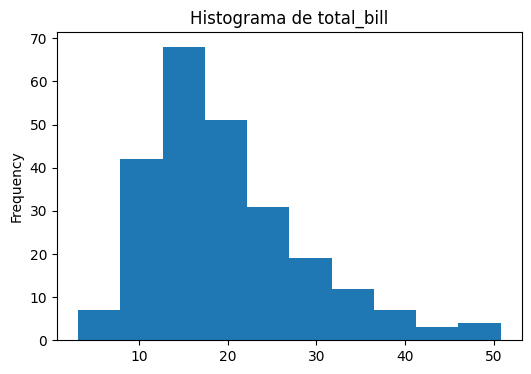

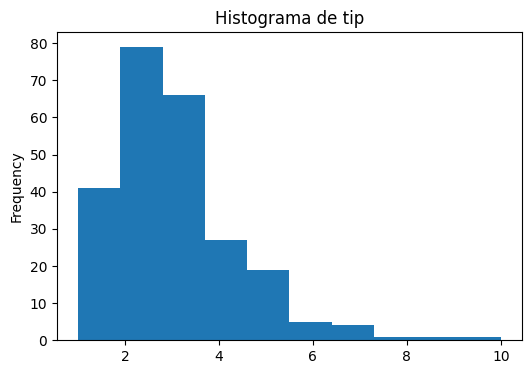

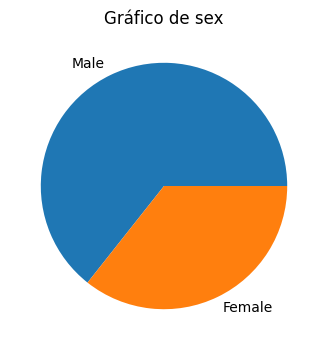

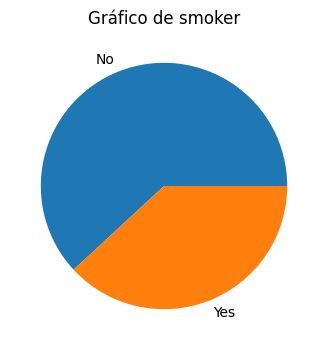

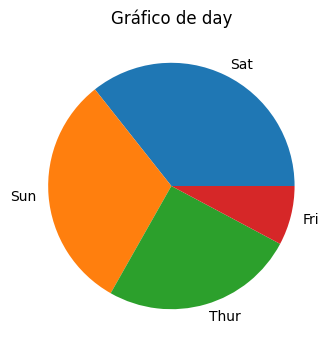

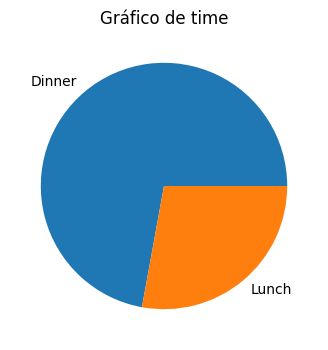

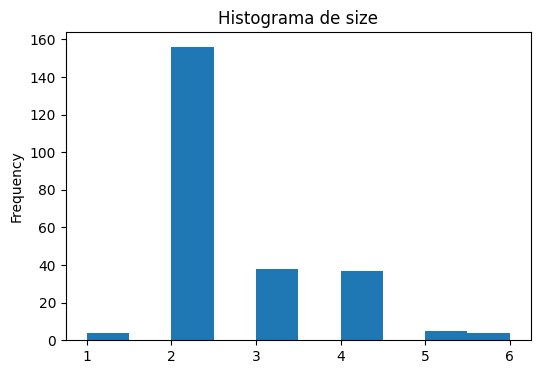

In [14]:
graficos_columnas_df(tips)

**2.**
Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: Mejores Rutas

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

In [2]:
import pandas as pd

matriz_distancias = pd.read_excel("matriu_distancies.xlsx")
matriz_distancias = matriz_distancias.rename(columns={"Unnamed: 0": "Ciudad"}).set_index("Ciudad")
#borrar filas
matriz_distancias.drop(["Palma", "Las Palmas de Gran Canaria"], axis=0, inplace=True)
#borrar columnas
matriz_distancias.drop(["Palma", "Las Palmas de Gran Canaria"],axis=1, inplace=True)

matriz_distancias

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Ciudad,,,,,,,,,,,,,
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0


In [ ]:
#Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui 
#el més curta possible que puguis, retornant una llista amb l'ordre de visita. 
#Dóna també la distància total recorreguda.
def calculo_ruta(matriz_ciudades, ciudad_origen):
    """
    función para calcular orden para visitar todas las ciudades teniendo en cuenta distancia más corta.
    input:
        matriz de distancias entre ciudades.
        ciudad de origen
    output:
        lista de ciudades visitadas en orden.
        distancia total recorrida.    
    """
    ciudades_visitar = list(matriz_ciudades.columns)
    ciudades_visitar.remove(ciudad_origen)
    ciudades_visitadas = [ciudad_origen]
    distancia_recorrida = 0
    ciudad_partida = ciudad_origen
    while ciudades_visitar:
        distancias = matriz_ciudades.loc[ciudad_partida, ciudades_visitar]
        ciudad_destino = distancias.idxmin()
        ciudades_visitadas.append(ciudad_destino)
        distancia_recorrida += matriz_ciudades.loc[ciudad_partida, ciudad_destino]
        ciudad_partida = ciudad_destino
        ciudades_visitar.remove(ciudad_destino)
    return ciudades_visitadas, distancia_recorrida

In [13]:
ruta, distancia = calculo_ruta(matriz_distancias, "Murcia")
print(f"La ruta propuesta es: {ruta}")
print(f"La distancia recorrida es: {distancia} km.")

La ruta propuesta es: ['Murcia', 'Alicante', 'Valencia', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Hospitalet de Llobregat', 'Barcelona']
La distancia recorrida es: 3082.0 km.


In [15]:
#Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat
def ciudad_ruta_corta(matriz_ciudades):
    """
    función para calcular la ciudad de origen con la ruta más corta.
    input:
        matris de distancias entre ciudades.
    output:
        ciudad de origen con menor distancia recorrida.
        distancia total recorrida.    
    """
    ciudad_origen = ""
    menor_distancia = float("inf") #infinito

    for ciudad in matriz_ciudades.index:
        ruta, distancia = calculo_ruta(matriz_ciudades, ciudad)
        if distancia < menor_distancia:
            ciudad_origen = ciudad
            menor_distancia = distancia

    return ciudad_origen, menor_distancia

In [16]:
ciudad, distancia = ciudad_ruta_corta(matriz_distancias)
print(f"La ciudad de origen con menor distancia total recorrida es: {ciudad}")
print(f"La distancia recorrida es: {distancia} km.")

La ciudad de origen con menor distancia total recorrida es: Barcelona
La distancia recorrida es: 2778.0 km.
